In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

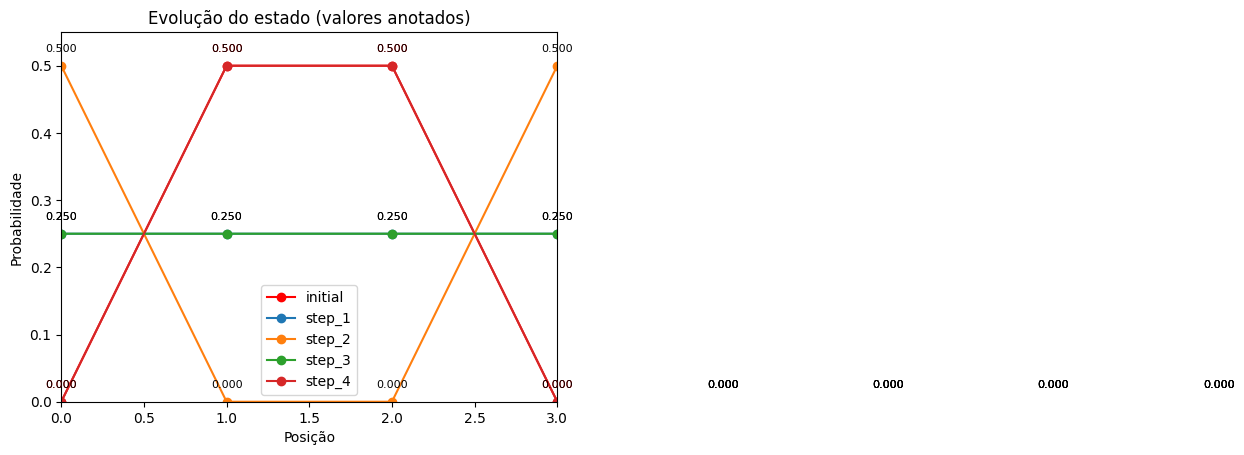

In [2]:
import numpy as np
from numpy import pi
from qiskit import QuantumCircuit
from qiskit import ClassicalRegister, QuantumRegister
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import pandas as pd

#Retorna o vetor de estado final (|ψ⟩) do circuito 'qc' como array complexo do NumPy."""
def sim_sv(qc):
    from qiskit.quantum_info import Statevector
    sv = Statevector.from_instruction(qc).data
    return sv

#QFT Caseira| Início
def qft_rotations(circuit):
    circuit.h(1)
    circuit.cp(pi/2, 0, 1)
    circuit.h(0)
    circuit.swap(0,1)
    return circuit

def makeQFTgate(N):
    temp = QuantumCircuit(N)        # cria um circuito temporário com N qubits
    qft_rotations(temp)             # aplica as rotações da QFT (sem swaps) no circuito
    QFTC = temp.to_gate()           # converte o circuito em uma única porta reutilizável
    return QFTC                     # retorna a porta QFT para ser anexada em outros circuitos
#QFT Caseira| Fim

def phase(n, phi):
    qc = QuantumCircuit(n+1)
    # fases locais nos dados
    qc.rz(1*phi, 0)
    qc.rz(2*phi, 1)
    # acumula paridade na ancilla (CNOT de cada dado -> ancilla)
    qc.cx(0, 2)
    qc.cx(1, 2)
    # fase dependente da paridade na ancilla
    qc.rz(2* phi, 2)
    # desfaz os CNOTs (limpa a ancilla)
    qc.cx(1, 2)
    qc.cx(0, 2)
    phcirc = qc.to_gate()

    return phcirc

def evolve (N,phi,initial_state, stepsnumber):
    #faz um novo circuito
    N1 = N+1
    snaps = []

    #qubits
    for i in range (stepsnumber):
        q = QuantumRegister(N1)
        qc = QuantumCircuit(q)

        #initialization
        qc.initialize(initial_state, list(range(n)))

        #QFT
        QFT = makeQFTgate(n)
        qc.append(QFT,range(n))

        #APLICA A MATRIZ DE PERMUTAÇÃO P = X ⊗ I
        qc.x(0)

        #phase
        ph = phase (2,(i+1)*phi)
        qc.append(ph,range(n+1))

        #APLICA A MATRIZ DE PERMUTAÇÃO P = X ⊗ I
        qc.x(0)

        #inverse QFT
        QFTi = QFT.inverse()
        qc.append(QFTi,list(range(n)))

        #final state + probabilitie
        finalstate = sim_sv(qc)
        prob = np.square(abs(finalstate))
        snaps.append(prob)

    return snaps

def action():
    snaps = evolve(n, phi, initial_state, stepsnumber)

    # Gráfico inicial (estado inicial em vermelho)
    plt.plot(np.square(abs(initial_state)), 'r', marker='o')
    leg = ["initial"]

    # Adiciona os pontos e valores para o estado inicial
    for j, y in enumerate(np.square(abs(initial_state))):
        plt.text(j, y + 0.02, f"{y:.3f}", ha='center', color='r', fontsize=8)

    # Plota os passos da evolução
    for i in range(stepsnumber):
        plt.plot(snaps[i], marker='o')
        leg.append("step_" + str(i + 1))
        # Adiciona os valores sobre cada ponto
        for j, y in enumerate(snaps[i]):
            plt.text(j, y + 0.02, f"{y:.3f}", ha='center', fontsize=8)

    # Ajusta eixos e legenda
    plt.axis([0, 2**n - 1, 0, 1.1 * max(np.square(abs(initial_state)))])
    plt.legend(leg)
    plt.xlabel("Posição")
    plt.ylabel("Probabilidade")
    plt.title("Evolução do estado (valores anotados)")
    plt.show()

    return snaps

##parameters
n=2
delta_t=2/pi
phi=(pi**2/4)*delta_t; ##time of evolution

initial_state = np.array([0, 1, 1, 0], dtype=complex)
magnitude = np.linalg.norm(initial_state)
initial_state =initial_state/magnitude


stepsnumber =  4;
snaps=action()


In [3]:
# Configuração da figura (sem eixos visíveis)
fig, ax = plt.subplots()
ax.axis('off')  # remove eixos e moldura

# Define limites (ainda necessários para a animação)
ax.set_xlim((0, (2**n) - 1))
ax.set_ylim((0, 1.1 * max(np.square(abs(initial_state)))))

# Linha que será atualizada na animação
line, = ax.plot([], [], lw=2, color='deepskyblue')

# Função de inicialização: limpa o quadro
def init():
    line.set_data([], [])
    return (line,)

# Função de animação: atualiza o gráfico a cada frame
def animate(i):
    x = list(range(2**(n + 1)))
    y = snaps[i]
    line.set_data(x, y)
    return (line,)

# Cria a animação
anim = animation.FuncAnimation(
    fig, animate, init_func=init, frames=stepsnumber, interval=200, blit=True
)

# Mostra apenas o vídeo (sem gráfico fixo)
plt.close(fig)
HTML(anim.to_html5_video())

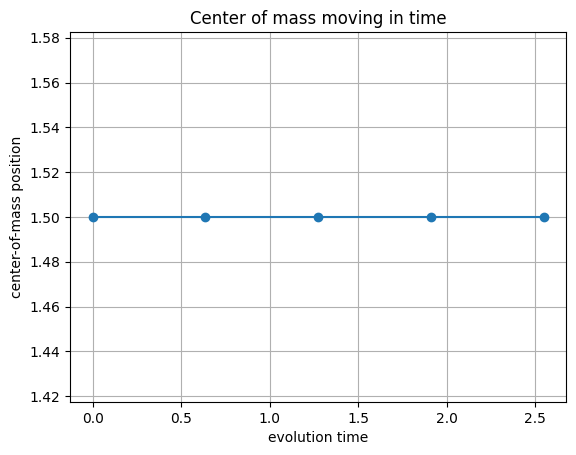

In [4]:
def reduce_over_ancilla(prob_full, n):
    """Soma a prob. sobre a ancilla: 2^(n+1) -> 2^n."""
    L = 2**n
    prob_full = np.asarray(prob_full)
    if prob_full.size == L:
        return prob_full
    if prob_full.size != 2*L:
        raise ValueError("Vetor de probabilidade com tamanho inesperado.")
    return prob_full[:L] + prob_full[L:]

def com_initial(initial_state):
    """Centro de massa do estado inicial (já sem ancilla)."""
    p0 = np.abs(np.asarray(initial_state))**2
    p0 = p0 / p0.sum()
    xs = np.arange(p0.size)
    return float(xs @ p0)

def com_snaps(snaps, n):
    """Centro de massa para cada snap (reduzindo a ancilla)."""
    L = 2**n
    xs = np.arange(L)
    out = []
    for p in snaps:
        p_red = reduce_over_ancilla(p, n)
        p_red = p_red / p_red.sum()
        out.append(float(xs @ p_red))
    return np.array(out, dtype=float)

# tempos (inclui t = 0)
t = np.arange(0, stepsnumber + 1) * float(delta_t)

# COM inicial + COM após cada passo
x0 = com_initial(initial_state)
x_com_steps = com_snaps(snaps, n)
x_com_traj = np.concatenate([[x0], x_com_steps])

# gráfico
plt.figure()
plt.plot(t, x_com_traj, marker='o')
plt.xlabel("evolution time")
plt.ylabel("center-of-mass position")
plt.title("Center of mass moving in time")
plt.grid(True)
plt.show()